In [42]:
import os
import numpy as np
from tifffile import TiffFile, imwrite
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
# New directory input code below

In [43]:
# --- Cell 2: Summarize frames in a given tiff directory ---
def auto_contrast_image(mean_img, percent_low=0.5, percent_high=99.5):
    """Auto-contrast stretch based on percentiles."""
    min_val = np.percentile(mean_img, percent_low)
    max_val = np.percentile(mean_img, percent_high)
    print(f"Auto-contrast: min={min_val:.2f}, max={max_val:.2f}")
    
    stretched = np.clip((mean_img - min_val) / (max_val - min_val + 1e-8), 0, 1)
    stretched_16bit = (stretched * 65535).astype(np.uint16)
    
    return stretched_16bit, stretched  # return both 16-bit and 0–1 float version

In [44]:
# --- Cell 3: Extract frames, save concatenated TIFF and mean projections ---
def extract_and_save_all_outputs(tiff_dir, tiff_files, frame_start, frame_end, output_dir, base_name):
    os.makedirs(output_dir, exist_ok=True)

    current_frame = 0
    selected_frames = []

    print(f"\nProcessing: {base_name}")
    print(f"Extracting frames {frame_start} to {frame_end}...")

    for fname in tqdm(tiff_files, desc="Loading TIFFs"):
        path = os.path.join(tiff_dir, fname)
        with TiffFile(path) as tif:
            for page in tif.pages:
                if frame_start <= current_frame <= frame_end:
                    selected_frames.append(page.asarray())
                current_frame += 1
                if current_frame > frame_end:
                    break
        if current_frame > frame_end:
            break

    if not selected_frames:
        print("No frames extracted!")
        return

    selected_array = np.stack(selected_frames, axis=0)
    print(f"Extracted {selected_array.shape[0]} frames.")

    # --- Save concatenated TIFF stack ---
    output_stack_tiff = os.path.join(output_dir, f'{base_name}_stack.tiff')
    imwrite(output_stack_tiff, selected_array)
    print(f"Saved concatenated stack: {output_stack_tiff}")

    # --- Mean Projection ---
    mean_img = selected_array.mean(axis=0)

    # Save normal mean TIFF
    mean_normal_tiff = os.path.join(output_dir, f'{base_name}_mean.tiff')
    imwrite(mean_normal_tiff, mean_img.astype(np.float32))
    print(f"Saved normal mean TIFF: {mean_normal_tiff}")

    # Save normal mean PNG
    mean_normal_png = os.path.join(output_dir, f'{base_name}_mean.png')
    plt.imsave(mean_normal_png, mean_img, cmap='gray')
    print(f"Saved normal mean PNG: {mean_normal_png}")

    # --- Auto-Contrast ---
    mean_autocontrast_16bit, mean_autocontrast_float = auto_contrast_image(mean_img)

    # Save autocontrast mean TIFF
    mean_auto_tiff = os.path.join(output_dir, f'{base_name}_mean_autocontrast.tiff')
    imwrite(mean_auto_tiff, mean_autocontrast_16bit)
    print(f"Saved autocontrast mean TIFF: {mean_auto_tiff}")

    # Save autocontrast mean PNG
    mean_auto_png = os.path.join(output_dir, f'{base_name}_mean_autocontrast.png')
    plt.imsave(mean_auto_png, mean_autocontrast_float, cmap='gray')
    print(f"Saved autocontrast mean PNG: {mean_auto_png}")

In [45]:
def process_all_planes(input_root, output_root, frame_start, frame_end):
    # Find all plane folders
    plane_folders = [d for d in os.listdir(input_root) if d.startswith('plane_') and os.path.isdir(os.path.join(input_root, d))]

    for plane_folder in sorted(plane_folders):
        tiff_dir = os.path.join(input_root, plane_folder, 'suite2p', 'plane0', 'reg_tif')
        if not os.path.exists(tiff_dir):
            print(f"Warning: No reg_tif folder found for {plane_folder}")
            continue

        # Find TIFF files
        tiff_files = sorted([f for f in os.listdir(tiff_dir) if f.endswith(('.tif', '.tiff'))])
        if not tiff_files:
            print(f"Warning: No TIFFs found in {tiff_dir}")
            continue

        # Create output plane folder
        out_dir = os.path.join(output_root, plane_folder)
        os.makedirs(out_dir, exist_ok=True)

        # Base name for output files
        base_name = f"{plane_folder}_frames_{frame_start}_to_{frame_end}"

        # Run extraction and saving
        extract_and_save_all_outputs(tiff_dir, tiff_files, frame_start, frame_end, out_dir, base_name)

    print("\n✅ Finished processing all planes.")

In [61]:
# --- USER INPUT ---
input_root = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/suite2p_full_output'  # <-- your INPUT root
output_root = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed'  # <-- your OUTPUT root

frame_start = 0  # starting frame
frame_end = 3000  # ending frame

# --- Run ---
process_all_planes(input_root, output_root, frame_start, frame_end)


Processing: plane_1_frames_0_to_3000
Extracting frames 0 to 3000...


Loading TIFFs:   4%|▍         | 6/141 [00:11<04:21,  1.94s/it]


Extracted 3001 frames.
Saved concatenated stack: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_1/plane_1_frames_0_to_3000_stack.tiff
Saved normal mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_1/plane_1_frames_0_to_3000_mean.tiff
Saved normal mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_1/plane_1_frames_0_to_3000_mean.png
Auto-contrast: min=-17.51, max=3407.22
Saved autocontrast mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_1/plane_1_frames_0_to_3000_mean_autocontrast.tiff
Saved autocontrast mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_1/plane_1_frames_0_to_3000_mean_autocontrast.png

Processing: plane_10_frames_0_to_3000
Extracting frames 0 to 3000...


Loading TIFFs:   4%|▍         | 6/141 [00:11<04:24,  1.96s/it]


Extracted 3001 frames.
Saved concatenated stack: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_10/plane_10_frames_0_to_3000_stack.tiff
Saved normal mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_10/plane_10_frames_0_to_3000_mean.tiff
Saved normal mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_10/plane_10_frames_0_to_3000_mean.png
Auto-contrast: min=-18.47, max=2582.12
Saved autocontrast mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_10/plane_10_frames_0_to_3000_mean_autocontrast.tiff
Saved autocontrast mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_10/plane_10_frames_0_to_3000_mean_autocontrast.png

Processing: plane_11_frames_0_to_3000
Extracting frames 0 to 3000...


...

Extracted 3001 frames.
Saved concatenated stack: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_7/plane_7_frames_0_to_3000_stack.tiff
Saved normal mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_7/plane_7_frames_0_to_3000_mean.tiff
Saved normal mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_7/plane_7_frames_0_to_3000_mean.png
Auto-contrast: min=-17.89, max=3234.40
Saved autocontrast mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_7/plane_7_frames_0_to_3000_mean_autocontrast.tiff
Saved autocontrast mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_7/plane_7_frames_0_to_3000_mean_autocontrast.png

Processing: plane_8_frames_0_to_3000
Extracting frames 0 to 3000...


Loading TIFFs:   4%|▍         | 6/141 [00:11<04:28,  1.99s/it]


Extracted 3001 frames.
Saved concatenated stack: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_8/plane_8_frames_0_to_3000_stack.tiff
Saved normal mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean.tiff
Saved normal mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean.png
Auto-contrast: min=-18.01, max=3102.81
Saved autocontrast mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean_autocontrast.tiff
Saved autocontrast mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean_autocontrast.png

Processing: plane_9_frames_0_to_3000
Extracting frames 0 to 3000...


Loading TIFFs:   4%|▍         | 6/141 [00:11<04:23,  1.95s/it]


Extracted 3001 frames.
Saved concatenated stack: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_9/plane_9_frames_0_to_3000_stack.tiff
Saved normal mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_9/plane_9_frames_0_to_3000_mean.tiff
Saved normal mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_9/plane_9_frames_0_to_3000_mean.png
Auto-contrast: min=-18.24, max=2931.18
Saved autocontrast mean TIFF: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_9/plane_9_frames_0_to_3000_mean_autocontrast.tiff
Saved autocontrast mean PNG: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk303/mk303_02_28_2025/green_processed/plane_9/plane_9_frames_0_to_3000_mean_autocontrast.png

✅ Finished processing all planes.


In [ ]:
# Testing

In [33]:
import os
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.image as mpimg

In [35]:


# ===== USER INPUT =====
input_root = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/red_registered_before_only_processed'  # Folder containing all plane folders
output_png = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/red_collage3.png'          # Path to save the output collage
image_suffix = '_frames_0_to_1000_mean_autocontrast.png'  # pattern for the images to find
ncols = 4   # number of columns in collage (you can adjust!)
label_fontsize = 10  # size of the plane labels
# ======================

# --- Step 1: Find images ---
plane_folders = sorted([d for d in os.listdir(input_root) if os.path.isdir(os.path.join(input_root, d))])

images = []
labels = []

for plane_folder in plane_folders:
    img_path = os.path.join(input_root, plane_folder, f"{plane_folder}{image_suffix}")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        images.append(img)
        labels.append(plane_folder)
    else:
        print(f"Warning: {img_path} not found, skipping.")

# --- Step 2: Build collage ---
n_images = len(images)
nrows = (n_images + ncols - 1) // ncols  # ceiling division

fig = plt.figure(figsize=(ncols * 4, nrows * 4))
gs = gridspec.GridSpec(nrows, ncols, wspace=0.4, hspace=0.4)

for idx, (img, label) in enumerate(zip(images, labels)):
    ax = fig.add_subplot(gs[idx])
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(label, fontsize=label_fontsize)

# --- Step 3: Save collage ---
plt.tight_layout()
fig.savefig(output_png, dpi=300)
plt.close(fig)

print(f"Saved collage to {output_png}")

/var/folders/0b/c0pl62111tv9fw6rp_8d85s40000gn/T/ipykernel_36217/1470226253.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved collage to /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/red_collage3.png


In [ ]:
#Quick test

# --- Path to your ops.npy file ---
ops_path = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_03_01_2025/red_registered_before_only/plane_10/suite2p/plane0/ops.npy'  # e.g., '/data/plane_1/suite2p/plane0/ops.npy'

# --- Load ops dict ---
ops = np.load(ops_path, allow_pickle=True).item()

# --- Print all key-value pairs ---
print("Suite2p ops parameters:\n")
for key, value in ops.items():
    print(f"{key}: {value}")

Suite2p ops parameters:

suite2p_version: 0.14.4
look_one_level_down: False
fast_disk: /v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_03_01_2025/red_registered_before_only/plane_10
delete_bin: True
mesoscan: False
bruker: False
bruker_bidirectional: False
h5py: []
h5py_key: data
nwb_file: 
nwb_driver: 
nwb_series: 
save_path0: /v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_03_01_2025/red_registered_before_only/plane_10
save_folder: suite2p
subfolders: []
move_bin: False
nplanes: 1
nchannels: 1
functional_chan: 1
tau: 1.0
fs: 17.07
force_sktiff: False
frames_include: -1
multiplane_parallel: False
ignore_flyback: []
preclassify: 0.0
save_mat: False
save_NWB: False
combined: True
aspect: 1.0
do_bidiphase: False
bidiphase: 0
bidi_corrected: False
do_registration: True
two_step_registration: True
keep_movie_raw: True
nimg_init: 300
batch_size: 300
maxregshift: 0.1
align_by_chan: 1
reg_tif: True
reg_tif_chan2: False
subpixel: 10
smooth_sigma_time: 0
smooth_sigma: 1.15
th_badframes: 1.0
norm_

In [13]:
#Old single folder code below

In [11]:
# --- Cell 2: Count TIFFs and Frames ---

tiff_dir = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/red_registered_before_only/plane_8/suite2p/plane0/reg_tif'

def summarize_tiff_directory(tiff_dir):
    tiff_files = sorted([f for f in os.listdir(tiff_dir) if f.endswith(('.tif', '.tiff'))])
    print(f"Found {len(tiff_files)} TIFF files in folder: {tiff_dir}\n")

    total_frames = 0
    frames_per_file = []

    for f in tqdm(tiff_files, desc="Counting frames"):
        with TiffFile(os.path.join(tiff_dir, f)) as tif:
            n_frames = len(tif.pages)
            frames_per_file.append(n_frames)
            total_frames += n_frames

    for i, (f, n) in enumerate(zip(tiff_files, frames_per_file)):
        print(f"File {i+1}: {f} --> {n} frames")

    print(f"\nTotal frames across all TIFFs: {total_frames}")
    return tiff_files, frames_per_file, total_frames

tiff_files, frames_per_file, total_frames = summarize_tiff_directory(tiff_dir)


Found 5 TIFF files in folder: /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/red_registered_before_only/plane_8/suite2p/plane0/reg_tif



Counting frames: 100%|██████████| 5/5 [00:00<00:00, 31.73it/s]

File 1: file00000_chan0.tif --> 200 frames
File 2: file00200_chan0.tif --> 200 frames
File 3: file00400_chan0.tif --> 200 frames
File 4: file00600_chan0.tif --> 200 frames
File 5: file00800_chan0.tif --> 200 frames

Total frames across all TIFFs: 1000


In [12]:
from matplotlib import pyplot as plt  # <- Make sure this is imported at the top

# ==== USER INPUT ====
frame_start = 0  # replace with your desired starting frame
frame_end = 1000    # exclusive, like Python slicing
output_dir = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/red_registered_before_only_test/'  # folder where files will be saved


# --- Cell 3: Extract frame range and save new TIFF and mean image ---
def extract_and_save_frames(tiff_dir, tiff_files, frame_start, frame_end, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    current_frame = 0
    selected_frames = []

    print(f"Extracting frames from {frame_start} to {frame_end}...")

    for fname in tqdm(tiff_files):
        path = os.path.join(tiff_dir, fname)
        with TiffFile(path) as tif:
            for page in tif.pages:
                if frame_start <= current_frame <= frame_end:
                    selected_frames.append(page.asarray())
                current_frame += 1
                if current_frame > frame_end:
                    break
        if current_frame > frame_end:
            break

    selected_array = np.stack(selected_frames, axis=0)
    print(f"Extracted {selected_array.shape[0]} frames. Saving...")

    # Save concatenated TIFF
    output_tiff = os.path.join(output_dir, 'mk301_02_05_2025_red_registered.tiff')
    imwrite(output_tiff, selected_array)
    print(f"Saved concatenated TIFF to {output_tiff}")

    # Compute mean projection
    mean_img = selected_array.mean(axis=0)

    # Save as TIFF
    output_mean_tiff = os.path.join(output_dir, 'mk301_02_05_2025_red_registered_mean_projection.tiff')
    imwrite(output_mean_tiff, mean_img.astype(np.float32))
    print(f"Saved mean projection TIFF to {output_mean_tiff}")

    # Save as PNG
    output_mean_png = os.path.join(output_dir, 'mk301_02_05_2025_red_registered_registered_mean_projection.png')
    plt.imsave(output_mean_png, mean_img, cmap='gray')
    print(f"Saved mean projection PNG to {output_mean_png}")

    # --- Call the function ---
extract_and_save_frames(tiff_dir, tiff_files, frame_start, frame_end, output_dir)

    

Extracting frames from 0 to 1000...


100%|██████████| 5/5 [00:04<00:00,  1.14it/s]


Extracted 1000 frames. Saving...
Saved concatenated TIFF to /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/red_registered_before_only_test/mk301_02_05_2025_red_registered.tiff
Saved mean projection TIFF to /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/red_registered_before_only_test/mk301_02_05_2025_red_registered_mean_projection.tiff
Saved mean projection PNG to /Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/red_registered_before_only_test/mk301_02_05_2025_red_registered_registered_mean_projection.png


In [6]:
# --- USER INPUT ---
suite2p_session_1 = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/mk301_2_05_2025_suite2p_full_output/plane_8/suite2p/plane0'  # change plane if needed
suite2p_session_2 = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_17_2025/mk301_2_17_2025_suite2p_full_output/plane_8/suite2p/plane0'
cell_prob_threshold = 0.4

# Load stat.npy and iscell.npy from each session
def load_filtered_cells(suite2p_dir, threshold):
    stat = np.load(os.path.join(suite2p_dir, 'stat.npy'), allow_pickle=True)
    iscell = np.load(os.path.join(suite2p_dir, 'iscell.npy'))
    cell_probs = iscell[:, 1]
    good_cells = cell_probs > threshold
    return [stat[i] for i in range(len(stat)) if good_cells[i]]

roi_1 = load_filtered_cells(suite2p_session_1, cell_prob_threshold)
roi_2 = load_filtered_cells(suite2p_session_2, cell_prob_threshold)


In [ ]:
# Below is some plotting code for cell masks from Suite2p

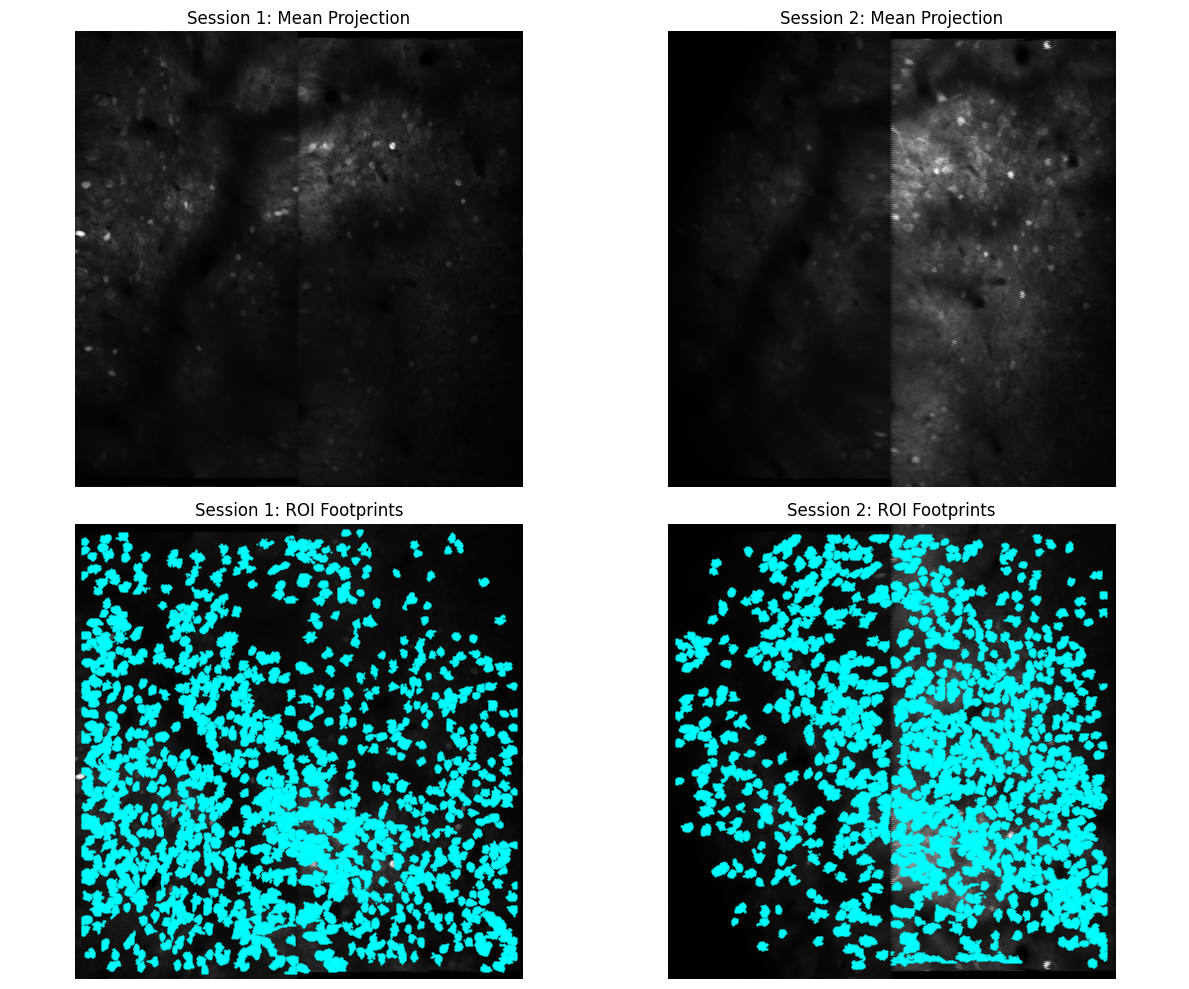

In [7]:
# --- USER INPUT ---
tiff_dir_session_1 = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_05_2025/mk301_2_05_2025_suite2p_full_output/plane_8/suite2p/plane0/reg_tif/file002500_chan0.tif'
tiff_dir_session_2 = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301_02_17_2025/mk301_2_17_2025_suite2p_full_output/plane_8/suite2p/plane0/reg_tif/file00500_chan0.tif'

def compute_mean_projection(tiff_input):
    if os.path.isfile(tiff_input):
        # If a single TIFF file is provided
        stack = tifffile.imread(tiff_input)
    else:
        # If a directory is provided, concatenate multiple TIFFs
        tiff_files = sorted(glob(os.path.join(tiff_input, '*.tif')))
        if len(tiff_files) == 0:
            raise ValueError(f"No TIFF files found in {tiff_input}")
        frames = [tifffile.imread(f) for f in tiff_files]
        stack = np.concatenate(frames, axis=0)
    
    return np.mean(stack, axis=0)

def plot_footprints(ax, rois, color='cyan'):
    for roi in rois:
        ypix = roi['ypix']
        xpix = roi['xpix']
        ax.plot(xpix, ypix, '.', markersize=1, color=color)
    ax.invert_yaxis()
    ax.axis('equal')
    ax.axis('off')

# Generate mean projections
mean_proj_1 = compute_mean_projection(tiff_dir_session_1)
mean_proj_2 = compute_mean_projection(tiff_dir_session_2)

# Plot side-by-side
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Session 1: ROIs and mean image
axs[0, 0].imshow(mean_proj_1, cmap='gray')
axs[0, 0].set_title('Session 1: Mean Projection')
axs[0, 0].axis('off')
axs[1, 0].imshow(mean_proj_1, cmap='gray')
plot_footprints(axs[1, 0], roi_1)
axs[1, 0].set_title('Session 1: ROI Footprints')

# Session 2: ROIs and mean image
axs[0, 1].imshow(mean_proj_2, cmap='gray')
axs[0, 1].set_title('Session 2: Mean Projection')
axs[0, 1].axis('off')
axs[1, 1].imshow(mean_proj_2, cmap='gray')
plot_footprints(axs[1, 1], roi_2)
axs[1, 1].set_title('Session 2: ROI Footprints')

plt.tight_layout()
plt.show()
